In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import linear_rainbow

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df_malaria = pd.read_csv("malaria_data.csv")

In [4]:
df_malaria.head()

,Child_ID,Altitude_m,Temperature_C,Humidity_pct,Precipitation_mm,Dist_to_Water_m,Soil_Type,Bird_Count,Parasite_Density_ul
0,1,1248,22.0,87.4,707.2,155.3,Sand,9,4757.0
1,2,2862,9.7,92.2,793.5,1054.5,Sand,13,1916.0
2,3,2249,15.6,48.1,596.0,798.3,Clay,7,3402.0
3,4,1876,20.2,91.0,558.1,537.1,Clay,13,3523.0
4,5,636,NaN,67.1,530.1,950.5,Clay,9,5706.0


**Variables Environnementales (Prédicteurs)  
Altitude_m : L'altitude mesurée en mètres. C'est souvent la variable clé car elle influence la température et la présence des moustiques.  
Temperature_C : La température moyenne en degrés Celsius.  
Humidity_pct : Le taux d'humidité relative en pourcentage. Un air humide favorise généralement la survie des moustiques.  
Precipitation_mm : Le niveau de précipitations en millimètres. Les pluies créent des gîtes larvaires (points d'eau stagnante).  
Dist_to_Water_m : La distance (en mètres) par rapport au point d'eau le plus proche. Plus on est près de l'eau, plus le risque de piqûre est élevé.  
Soil_Type : Le type de sol. Certains sols retiennent mieux l'eau que d'autres, favorisant les nids de moustiques.**

**Autres Variables  
Child_ID : L'identifiant unique de l'enfant testé. C'est une variable technique qui ne doit pas être incluse dans le modèle  
Bird_Count : Le nombre d'oiseaux observés dans la zone.cela sert d'indicateur de biodiversité ou de présence d'autres hôtes pour les insectes.  
Parasite_Density : C'est ta variable cible ($Y$). Elle représente la charge parasitaire dans le sang.**

In [5]:
# supression de la varaible Child_ID
df_malaria_1 = df_malaria.drop(columns= 'Child_ID')

# Info sur la base de donnees  

In [6]:
df_malaria_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Altitude_m           250 non-null    int64  
 1   Temperature_C        239 non-null    float64
 2   Humidity_pct         237 non-null    float64
 3   Precipitation_mm     250 non-null    float64
 4   Dist_to_Water_m      250 non-null    float64
 5   Soil_Type            250 non-null    str    
 6   Bird_Count           250 non-null    int64  
 7   Parasite_Density_ul  250 non-null    float64
dtypes: float64(5), int64(2), str(1)
memory usage: 16.7 KB


**Cette basse de donnees comprend 250 observations et 8 variables celle decrites plus haut.  
des varriables entieres (Altitude_m ,Bird_Count)  
des variables reelles (Temperature_C ,Humidity_pct ,Precipitation_mm ,Dist_to_Water_m ,Parasite_Density_ul : notre variable cible )  
et une variable categorielle (Soil_Type)**

In [7]:
df_malaria_1['Soil_Type'].unique()

<ArrowStringArray>
['Sand', 'Clay', 'Loam']
Length: 3, dtype: str

trois type de sols qui sont : sables , argile , Terre franche

# Verifions les valeurs manquantes

In [8]:
(df_malaria_1.isnull().sum()/len(df_malaria_1))*100

Altitude_m             0.0
Temperature_C          4.4
Humidity_pct           5.2
Precipitation_mm       0.0
Dist_to_Water_m        0.0
Soil_Type              0.0
Bird_Count             0.0
Parasite_Density_ul    0.0
dtype: float64

Nous avons des valeurs manquantes sur les temperatures et l'humidite . moins de 6%  

In [9]:
# supressions des valeurs manquante 
df_malaria_2 = df_malaria_1.dropna()

# Verifions la relation entre les differentes variables numerique 

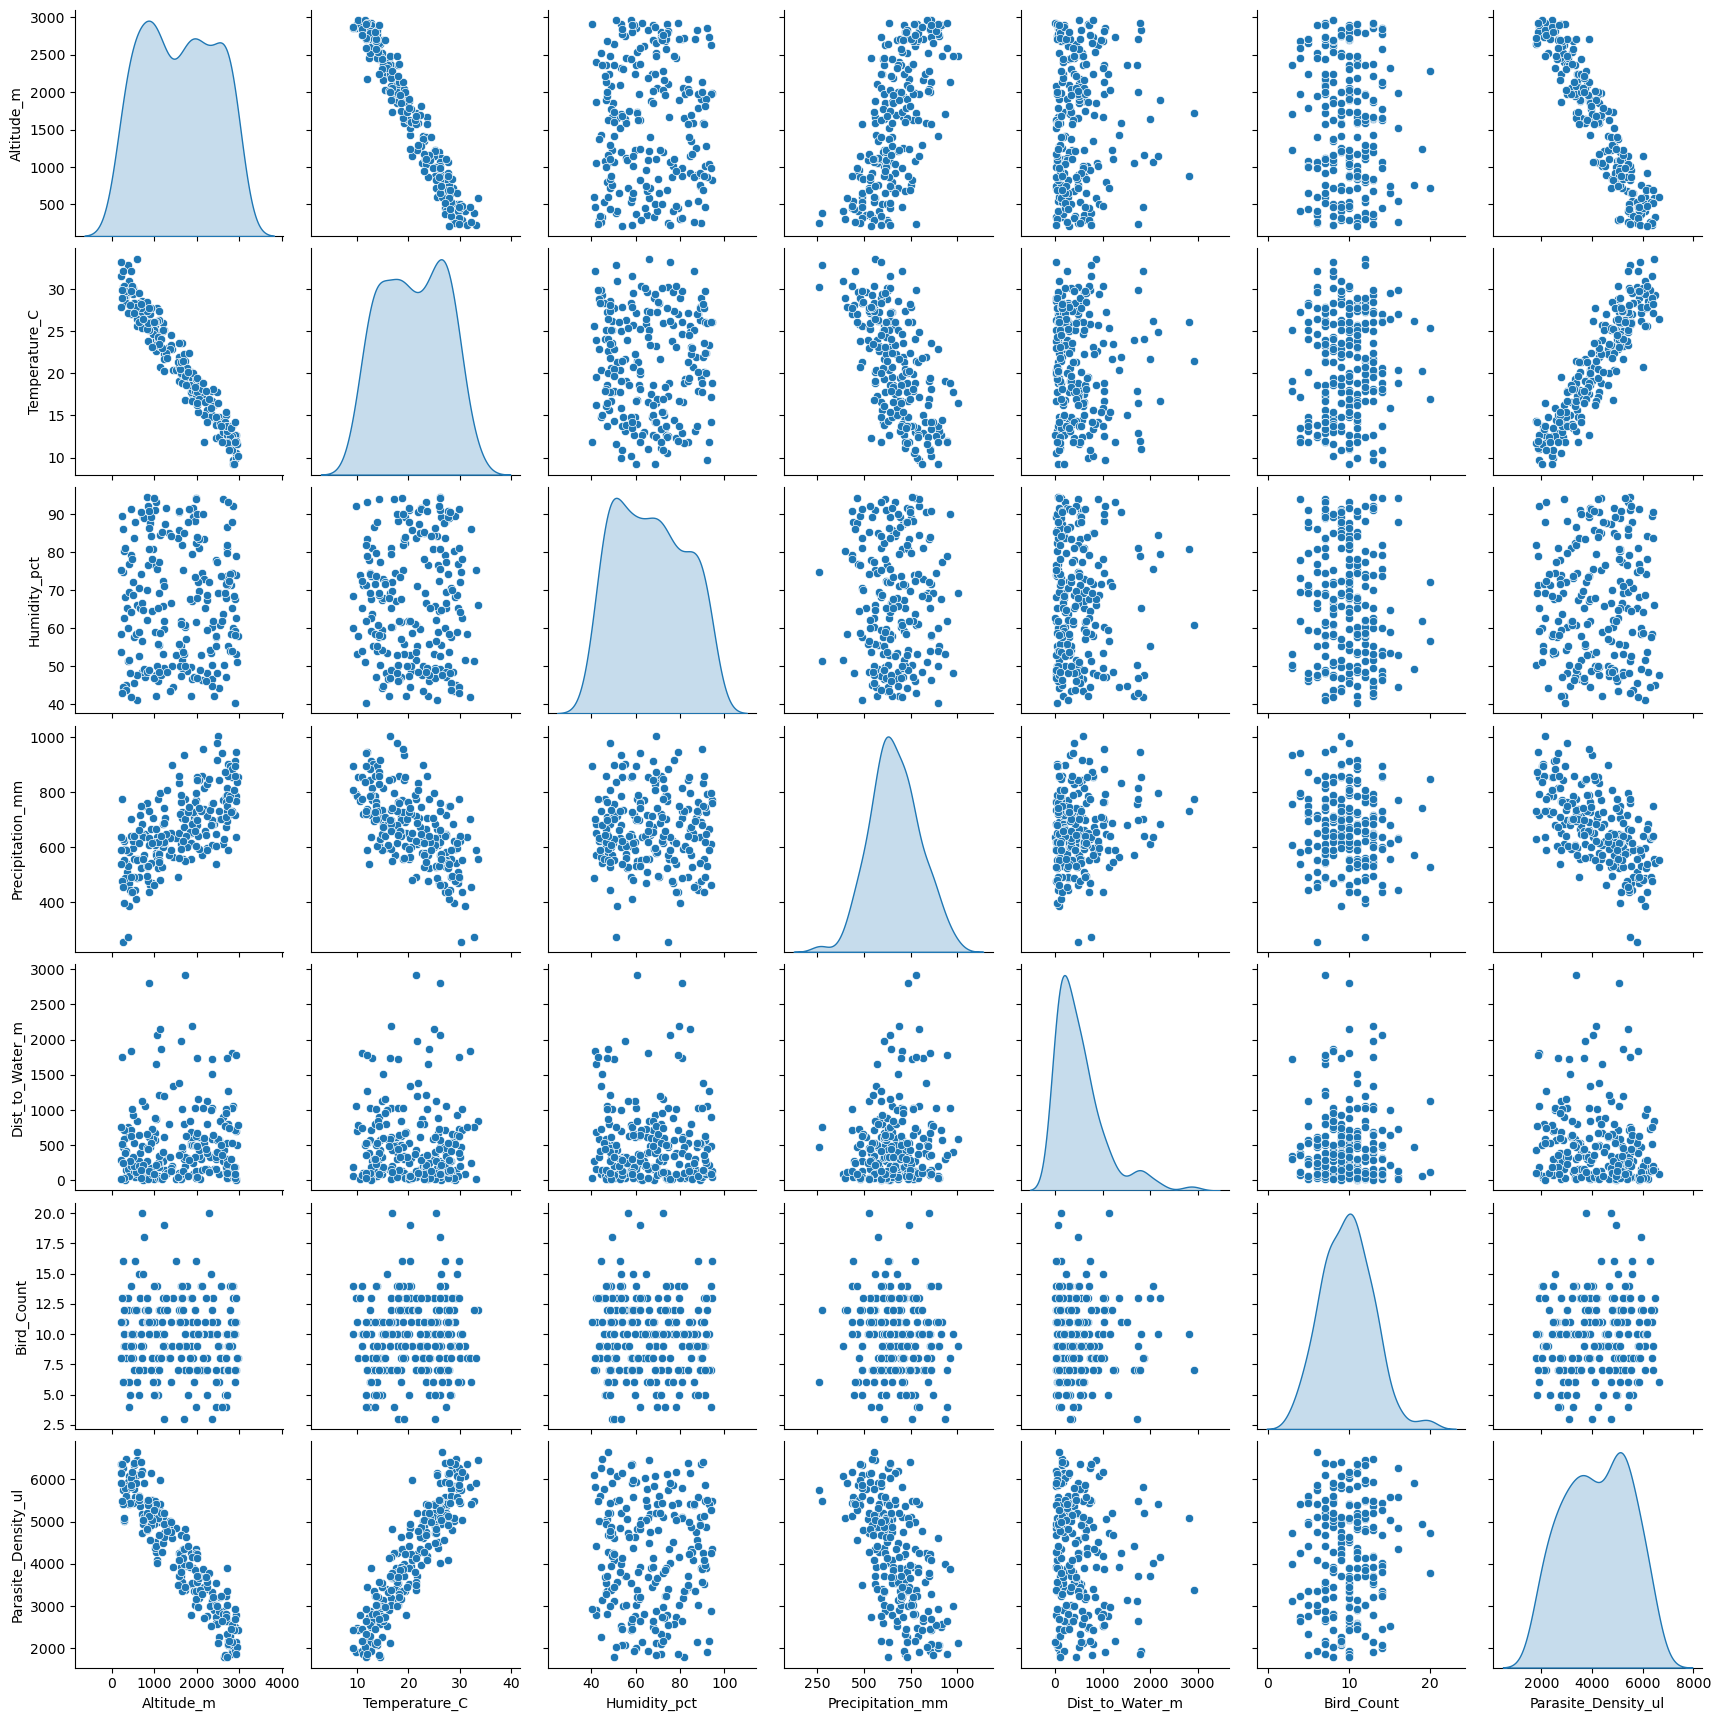

In [10]:
colonne_n=['Altitude_m','Temperature_C','Humidity_pct','Precipitation_mm','Dist_to_Water_m','Bird_Count','Parasite_Density_ul']

sns.pairplot(df_malaria_2[colonne_n], diag_kind='kde')
plt.show()

**On remarque qu'il ya une forte linearite ( relation lineaire ) entre :  
l'atitude et la temperature : plus l'altitude augmente , plus la temperature diminue   
l'atitude et la densite de parasite : plus l'altitude augmente plus plus la densite de parasite diminue  
la temperature et le densite de parasite : plus la temperature augmente plus la desite de parasite augmente  
on peut donc au lieu de suprimer les valeurs manquantes dans la colonne de la temperature ,faire une regression lineaire pour remplacer ces valeurs manquantes**

# Remplacement des valeurs manquantes de le temperature par une regression lineaire 

In [11]:
# on Isole les lignes avec et sans température
df_sans_null= df_malaria_1[df_malaria_1['Temperature_C'].notnull()]
df_null = df_malaria_1[df_malaria_1['Temperature_C'].isnull()]

# on Défini X (Altitude) et y (Température)
# On utilise l'altitude car c'est le meilleur prédicteur de la température selon les graphe du pairplot
X_train = df_sans_null[['Altitude_m']]
y_train = df_sans_null['Temperature_C']
X_nul = df_null[['Altitude_m']]

In [12]:
# Créer et entraîner le modèle d'imputation
model_null = LinearRegression()
model_null.fit(X_train, y_train)

# Prédire les valeurs manquantes
valeurs_predite = model_null.predict(X_nul)

# Remplacer les NaN dans le DataFrame original
df_malaria_1.loc[df_malaria_1['Temperature_C'].isnull(), 'Temperature_C'] = valeurs_predite

In [13]:
# notre dataframe propre 
df_malaria_3=df_malaria_1
# SUPRESSION DE VALEURS MANQUANTES POUR L'HUMIDITE
df_malaria_3=df_malaria_3.dropna()


# Place a la modelisation 

In [14]:
y = df_malaria_3['Parasite_Density_ul']
X = df_malaria_3[['Altitude_m', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Dist_to_Water_m','Bird_Count']]

# Ajout de la constante 
X = sm.add_constant(X)

## Regression lineaire 

In [15]:
# Création et ajustement du modèle OLS
model = sm.OLS(y, X).fit()

# Affichage du résumé 
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Parasite_Density_ul   R-squared:                       0.884
Model:                             OLS   Adj. R-squared:                  0.881
Method:                  Least Squares   F-statistic:                     291.6
Date:                 Tue, 14 Apr 2026   Prob (F-statistic):          1.66e-104
Time:                         14:35:28   Log-Likelihood:                -1774.8
No. Observations:                  237   AIC:                             3564.
Df Residuals:                      230   BIC:                             3588.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5882.1510   

## Verifions les hypothèses de Gauss-Markov

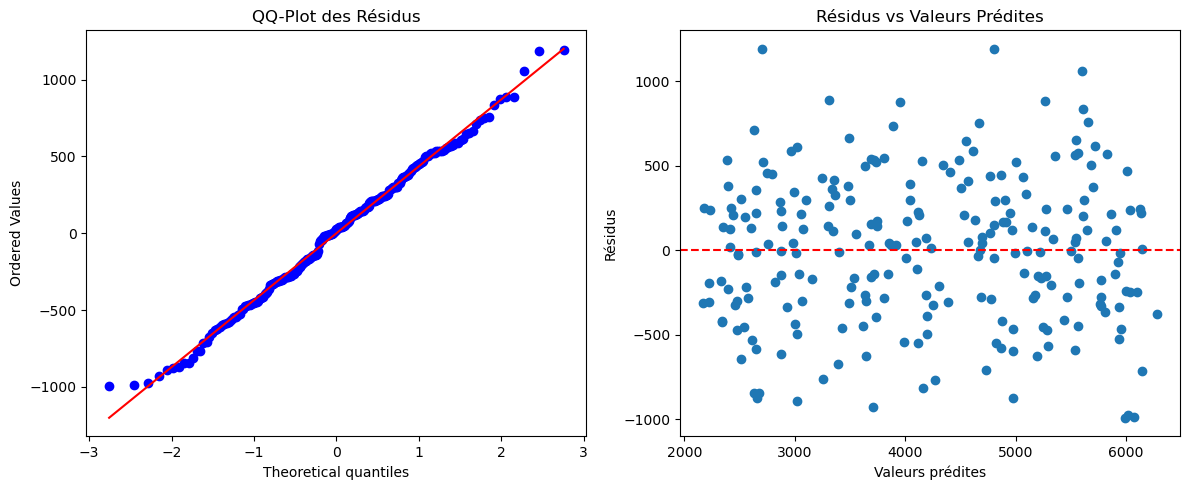

In [16]:
residus = model.resid
plt.figure(figsize=(12, 5))
# QQ-Plot pour la Normalité
plt.subplot(1, 2, 1)
stats.probplot(residus, dist="norm", plot=plt)
plt.title("QQ-Plot des Résidus")

# Résidus vs Valeurs Prédites (Homoscédasticité et Linéarité)
plt.subplot(1, 2, 2)
plt.scatter(model.predict(), residus)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('Résidus vs Valeurs Prédites')

plt.tight_layout()
plt.show()

**Le QQ-Plot des Résidus (À gauche)**  

Interprétation : Les points bleus sont quasiment tous collés à la ligne rouge diagonale.  
Il n'y a pas de courbure en "S" ni de décrochage majeur aux extrémités.  
Conclusion : Tes résidus suivent une loi normale. Tes tests de significativité ($p$-values) et ton AIC sont donc parfaitement valides et fiables sur ce modèle linéaire.

**Résidus vs Valeurs Prédites (À droite)**
C'est le test de l'homoscédasticité et de la linéarité.

Interprétation : Les points sont dispersés de manière totalement aléatoire (comme un "nuage de points") de part et d'autre de la ligne pointillée rouge.

Points positifs : * On ne voit pas de forme de "banane" (ce qui confirme que la relation est bien linéaire).

On ne voit pas de forme d'entonnoir (ce qui confirme que la variance est constante).

**Conclusion :**  
Toutes les hypothèses de Gauss-Markov sont respectées. modèle OLS ( Regression lineaire ) est l'estimateur optimal ici.

**Confirmation de la normalite des residus test de Shapiro-Wilk**

In [17]:
stat, p = stats.shapiro(residus)
print(f"\nTest de Shapiro-Wilk: Statistique={stat:.4f}, p-value={p:.4f}")

if p > 0.05:
    print("Verdict : Les résidus sont Normaux.")
else:
    print("Verdict : Les résidus ne sont PAS normaux.")


Test de Shapiro-Wilk: Statistique=0.9942, p-value=0.4934
Verdict : Les résidus sont Normaux.


**Nous pouvons passer a la selection des variables significative via le critere de l'AIC**

## Optimisation sur l'AIC

In [20]:
def selection_backward_aic(df, variable_cible, variables_explicatives_initiales):
    
    variables_courantes = variables_explicatives_initiales.copy()
    
    # Calcul de l'AIC initial avec toutes les variables
    X = sm.add_constant(df[variables_courantes])
    meilleur_modele = sm.OLS(df[variable_cible], X).fit()
    meilleur_aic = meilleur_modele.aic
    
    print(f"AIC initial : {meilleur_aic:.2f}")
    print("-" * 30)

    while True:
        changement = False
        
        # Récupération des p-values (sans la constante)
        p_values = meilleur_modele.pvalues.drop('const')
        
        # Variable la moins significative (p-value max)
        pire_variable = p_values.idxmax()
        plus_grande_p = p_values.max()

        # Nouveau modèle sans cette variable
        variables_restantes = [v for v in variables_courantes if v != pire_variable]
        X_temp = sm.add_constant(df[variables_restantes])
        modele_temp = sm.OLS(df[variable_cible], X_temp).fit()
        
        # Comparaison AIC
        if modele_temp.aic < meilleur_aic:
            print(f"Retrait de '{pire_variable}' (p-value: {plus_grande_p:.3f}) | Nouvel AIC : {modele_temp.aic:.2f}")
            
            meilleur_aic = modele_temp.aic
            meilleur_modele = modele_temp
            variables_courantes = variables_restantes
            changement = True
        
        if not changement:
            break
            
        print("-" * 30)

    print(f"Sélection terminée.")
    print(f"Variables conservées : {variables_courantes}")
    
    return meilleur_modele

In [21]:
toutes_les_variables = ['Altitude_m', 'Temperature_C', 'Humidity_pct', 
                        'Precipitation_mm', 'Dist_to_Water_m', 'Bird_Count']

# On lance la fonction
modele_final = selection_backward_aic(df_malaria_3, 'Parasite_Density_ul', toutes_les_variables)

# On affiche le résumé du modèle OPTIMAL
print(modele_final.summary())

AIC initial : 3563.52
------------------------------
Retrait de 'Bird_Count' (p-value: 0.788) | Nouvel AIC : 3561.59
------------------------------
Retrait de 'Temperature_C' (p-value: 0.649) | Nouvel AIC : 3559.81
------------------------------
Retrait de 'Humidity_pct' (p-value: 0.237) | Nouvel AIC : 3559.24
------------------------------
Retrait de 'Precipitation_mm' (p-value: 0.181) | Nouvel AIC : 3559.06
------------------------------
Sélection terminée.
Variables conservées : ['Altitude_m', 'Dist_to_Water_m']
                             OLS Regression Results                            
Dep. Variable:     Parasite_Density_ul   R-squared:                       0.882
Model:                             OLS   Adj. R-squared:                  0.881
Method:                  Least Squares   F-statistic:                     875.1
Date:                 Tue, 14 Apr 2026   Prob (F-statistic):          2.41e-109
Time:                         14:41:38   Log-Likelihood:                -1776.5